# 02 - Data Preprocessing
## Sistem Rekomendasi Produk Manufaktur

**Tujuan Notebook:**
- Membersihkan data berdasarkan insight dari EDA
- Menghapus missing values, outliers, dan data anomali
- Membuat User-Item Matrix untuk Collaborative Filtering
- Mempersiapkan data untuk Content-Based Filtering (TF-IDF)
- Menyimpan data bersih untuk tahap modeling

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Raw Data

In [2]:
# Load dataset
df = pd.read_csv('../data/online_retail_II.csv')

print(f"Original dataset shape: {df.shape}")
print(f"Total rows: {len(df):,}")
print(f"\nFirst few rows:")
df.head()

Original dataset shape: (1067371, 8)
Total rows: 1,067,371

First few rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning

### 3.1 Remove Missing Customer IDs

In [3]:
print("=== Step 1: Remove Missing Customer IDs ===")
print(f"Rows before: {len(df):,}")
print(f"Missing Customer IDs: {df['Customer ID'].isna().sum():,}")

df_clean = df[df['Customer ID'].notna()].copy()

print(f"Rows after: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

=== Step 1: Remove Missing Customer IDs ===
Rows before: 1,067,371
Missing Customer IDs: 243,007
Rows after: 824,364
Rows removed: 243,007


### 3.2 Remove Negative Quantities (Returns/Cancellations)

In [4]:
print("\n=== Step 2: Remove Negative Quantities ===")
print(f"Rows before: {len(df_clean):,}")
print(f"Negative quantities: {(df_clean['Quantity'] < 0).sum():,}")
print(f"Zero quantities: {(df_clean['Quantity'] == 0).sum():,}")

df_clean = df_clean[df_clean['Quantity'] > 0].copy()

print(f"Rows after: {len(df_clean):,}")


=== Step 2: Remove Negative Quantities ===
Rows before: 824,364
Negative quantities: 18,744
Zero quantities: 0
Rows after: 805,620


### 3.3 Remove Invalid Prices

In [5]:
print("\n=== Step 3: Remove Invalid Prices ===")
print(f"Rows before: {len(df_clean):,}")
print(f"Zero prices: {(df_clean['Price'] == 0).sum():,}")
print(f"Negative prices: {(df_clean['Price'] < 0).sum():,}")

df_clean = df_clean[df_clean['Price'] > 0].copy()

print(f"Rows after: {len(df_clean):,}")


=== Step 3: Remove Invalid Prices ===
Rows before: 805,620
Zero prices: 71
Negative prices: 0
Rows after: 805,549


### 3.4 Remove Missing Descriptions

In [6]:
print("\n=== Step 4: Remove Missing Descriptions ===")
print(f"Rows before: {len(df_clean):,}")
print(f"Missing descriptions: {df_clean['Description'].isna().sum():,}")

df_clean = df_clean[df_clean['Description'].notna()].copy()

print(f"Rows after: {len(df_clean):,}")


=== Step 4: Remove Missing Descriptions ===
Rows before: 805,549
Missing descriptions: 0
Rows after: 805,549


### 3.5 Remove Duplicates

In [7]:
print("\n=== Step 5: Remove Duplicates ===")
print(f"Rows before: {len(df_clean):,}")
print(f"Duplicate rows: {df_clean.duplicated().sum():,}")

df_clean = df_clean.drop_duplicates()

print(f"Rows after: {len(df_clean):,}")


=== Step 5: Remove Duplicates ===
Rows before: 805,549
Duplicate rows: 26,124
Rows after: 779,425


### 3.6 Clean Description Text

In [8]:
print("\n=== Step 6: Clean Description Text ===")

# Convert to lowercase
df_clean['Description'] = df_clean['Description'].str.lower()

# Remove extra whitespaces
df_clean['Description'] = df_clean['Description'].str.strip()

# Remove special characters (keep alphanumeric and spaces)
df_clean['Description'] = df_clean['Description'].str.replace('[^a-z0-9\s]', '', regex=True)

print("Description text cleaned!")
print("\nSample cleaned descriptions:")
print(df_clean['Description'].head(10).tolist())


=== Step 6: Clean Description Text ===
Description text cleaned!

Sample cleaned descriptions:
['15cm christmas glass ball 20 lights', 'pink cherry lights', 'white cherry lights', 'record frame 7 single size', 'strawberry ceramic trinket box', 'pink doughnut trinket pot', 'save the planet mug', 'fancy font home sweet home doormat', 'cat bowl', 'dog bowl  chasing ball design']


## 4. Feature Engineering

### 4.1 Calculate Total Revenue

In [9]:
# Calculate total revenue per transaction
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['Price']

print("Total Revenue calculated!")
print(f"\nRevenue statistics:")
print(df_clean['TotalRevenue'].describe())

Total Revenue calculated!

Revenue statistics:
count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalRevenue, dtype: float64


### 4.2 Convert Data Types

In [10]:
# Convert Customer ID to integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print("Data types converted!")
print("\nData types:")
print(df_clean.dtypes)

Data types converted!

Data types:
Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
Customer ID              int32
Country                 object
TotalRevenue           float64
dtype: object


## 5. Data Summary After Cleaning

In [11]:
print("\n" + "="*70)
print("DATA SUMMARY AFTER CLEANING")
print("="*70)

print(f"\nOriginal dataset: {len(df):,} rows")
print(f"Cleaned dataset: {len(df_clean):,} rows")
print(f"Rows removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

print(f"\nUnique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Unique products: {df_clean['StockCode'].nunique():,}")
print(f"Unique invoices: {df_clean['Invoice'].nunique():,}")
print(f"Unique countries: {df_clean['Country'].nunique()}")

print(f"\nTotal revenue: ${df_clean['TotalRevenue'].sum():,.2f}")
print(f"Average transaction value: ${df_clean['TotalRevenue'].mean():.2f}")

print(f"\nDate range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

print("\n" + "="*70)


DATA SUMMARY AFTER CLEANING

Original dataset: 1,067,371 rows
Cleaned dataset: 779,425 rows
Rows removed: 287,946 (26.98%)

Unique customers: 5,878
Unique products: 4,631
Unique invoices: 36,969
Unique countries: 41

Total revenue: $17,374,804.27
Average transaction value: $22.29

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00



## 6. Create User-Item Matrix

### 6.1 Aggregate Purchases by Customer and Product

In [12]:
print("=== Creating User-Item Matrix ===")

# Aggregate: sum of quantities purchased by each customer for each product
user_item_df = df_clean.groupby(['Customer ID', 'StockCode'])['Quantity'].sum().reset_index()

print(f"\nAggregated interactions: {len(user_item_df):,}")
print(f"Unique customers: {user_item_df['Customer ID'].nunique():,}")
print(f"Unique products: {user_item_df['StockCode'].nunique():,}")

user_item_df.head(10)

=== Creating User-Item Matrix ===

Aggregated interactions: 481,932
Unique customers: 5,878
Unique products: 4,631


,Customer ID,StockCode,Quantity
0,12346,15056BL,1
1,12346,15056N,1
2,12346,15056P,1
3,12346,20679,1
4,12346,20682,1
5,12346,20685,1
6,12346,21523,1
7,12346,21524,1
8,12346,21955,1
9,12346,22365,1


### 6.2 Create Pivot Table (User-Item Matrix)

In [13]:
# Create pivot table: rows = customers, columns = products, values = quantity
user_item_matrix = user_item_df.pivot(index='Customer ID', 
                                       columns='StockCode', 
                                       values='Quantity').fillna(0)

print(f"\nUser-Item Matrix shape: {user_item_matrix.shape}")
print(f"Rows (customers): {user_item_matrix.shape[0]:,}")
print(f"Columns (products): {user_item_matrix.shape[1]:,}")
print(f"Total cells: {user_item_matrix.shape[0] * user_item_matrix.shape[1]:,}")
print(f"Non-zero cells: {(user_item_matrix > 0).sum().sum():,}")
print(f"Sparsity: {(1 - (user_item_matrix > 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1])) * 100:.2f}%")

user_item_matrix.head(10)


User-Item Matrix shape: (5878, 4631)
Rows (customers): 5,878
Columns (products): 4,631
Total cells: 27,221,018
Non-zero cells: 481,932
Sparsity: 98.23%


StockCode,10002,10080,10109,10120,10123C,10123G,10124A,10124G,10125,10133,...,BANK CHARGES,C2,D,DOT,M,PADS,POST,SP1002,TEST001,TEST002
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,1.0
12347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0
12349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
12350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,7.0,0.0,0.0,0.0
12353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 6.3 Filter Low-Activity Users and Products

In [14]:
print("\n=== Filtering Low-Activity Users and Products ===")

# Set thresholds
MIN_USER_PURCHASES = 5   # Minimum products a user must have purchased
MIN_PRODUCT_PURCHASES = 5  # Minimum times a product must have been purchased

print(f"\nThresholds:")
print(f"  Min purchases per user: {MIN_USER_PURCHASES}")
print(f"  Min purchases per product: {MIN_PRODUCT_PURCHASES}")

# Count purchases per user and product
user_purchase_counts = (user_item_matrix > 0).sum(axis=1)
product_purchase_counts = (user_item_matrix > 0).sum(axis=0)

print(f"\nBefore filtering:")
print(f"  Users: {len(user_item_matrix):,}")
print(f"  Products: {len(user_item_matrix.columns):,}")

# Filter users
active_users = user_purchase_counts[user_purchase_counts >= MIN_USER_PURCHASES].index
user_item_matrix_filtered = user_item_matrix.loc[active_users]

# Filter products
active_products = product_purchase_counts[product_purchase_counts >= MIN_PRODUCT_PURCHASES].index
user_item_matrix_filtered = user_item_matrix_filtered[active_products]

print(f"\nAfter filtering:")
print(f"  Users: {len(user_item_matrix_filtered):,}")
print(f"  Products: {len(user_item_matrix_filtered.columns):,}")
print(f"  Sparsity: {(1 - (user_item_matrix_filtered > 0).sum().sum() / (user_item_matrix_filtered.shape[0] * user_item_matrix_filtered.shape[1])) * 100:.2f}%")


=== Filtering Low-Activity Users and Products ===

Thresholds:
  Min purchases per user: 5
  Min purchases per product: 5

Before filtering:
  Users: 5,878
  Products: 4,631

After filtering:
  Users: 5,545
  Products: 4,206
  Sparsity: 97.94%


## 7. Prepare Product Information

In [15]:
# Create product catalog with descriptions
product_info = df_clean.groupby('StockCode').agg({
    'Description': 'first',  # Take first description for each product
    'Price': 'mean',         # Average price
    'Quantity': 'sum',       # Total quantity sold
    'Customer ID': 'nunique' # Number of unique customers
}).reset_index()

product_info.columns = ['StockCode', 'Description', 'AvgPrice', 'TotalQuantitySold', 'UniqueCustomers']

# Filter to only include products in the filtered matrix
product_info = product_info[product_info['StockCode'].isin(user_item_matrix_filtered.columns)]

print(f"\nProduct catalog created!")
print(f"Total products: {len(product_info):,}")
print("\nSample products:")
product_info.head(10)


Product catalog created!
Total products: 4,206

Sample products:


,StockCode,Description,AvgPrice,TotalQuantitySold,UniqueCustomers
0,10002,inflatable political globe,0.840960,8479,164
1,10080,groovy cactus inflatable,0.509259,303,23
3,10120,doggy rubber,0.210000,648,52
4,10123C,hearts wrapping tape,0.621739,628,39
5,10123G,army camo wrapping tape,0.559231,2246,12
6,10124A,spots on red bookcover tape,0.420000,58,18
7,10124G,army camo bookcover tape,0.420000,32,9
8,10125,mini funky design tapes,0.815873,1970,87
9,10133,colouring pencils brown tube,0.655320,3307,153
10,10134,colouring pencils brown tube,1.242400,612,44


## 8. Save Processed Data

In [16]:
print("\n=== Saving Processed Data ===")

# Save cleaned transaction data
df_clean.to_csv('../data/transactions_cleaned.csv', index=False)
print(f"✓ Saved: transactions_cleaned.csv ({len(df_clean):,} rows)")

# Save user-item matrix
user_item_matrix_filtered.to_csv('../data/user_item_matrix.csv')
print(f"✓ Saved: user_item_matrix.csv ({user_item_matrix_filtered.shape[0]:,} x {user_item_matrix_filtered.shape[1]:,})")

# Save product information
product_info.to_csv('../data/products_cleaned.csv', index=False)
print(f"✓ Saved: products_cleaned.csv ({len(product_info):,} products)")

print("\nAll data saved successfully!")


=== Saving Processed Data ===
✓ Saved: transactions_cleaned.csv (779,425 rows)
✓ Saved: user_item_matrix.csv (5,545 x 4,206)
✓ Saved: products_cleaned.csv (4,206 products)

All data saved successfully!


## 9. Data Statistics Visualization

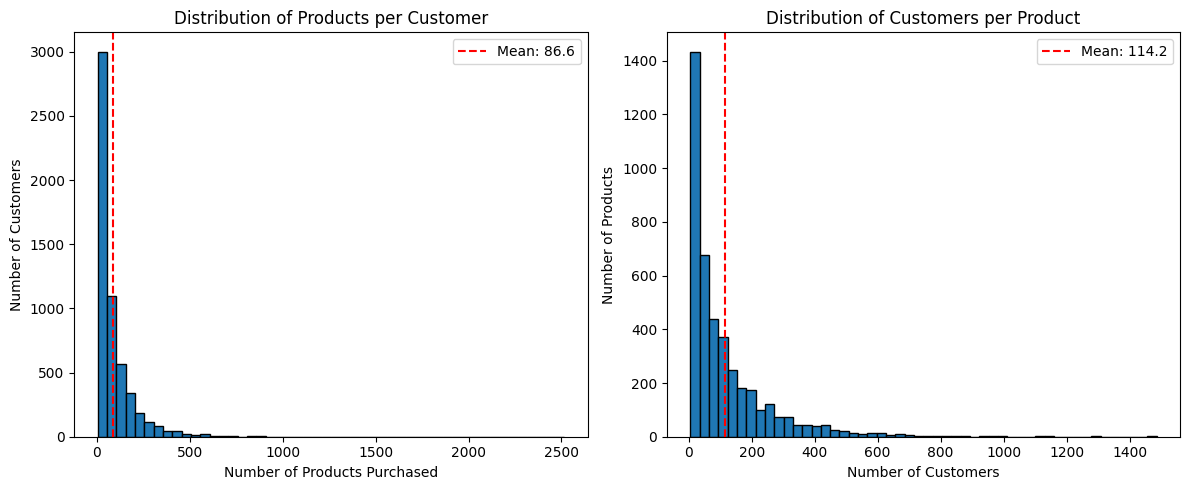

In [17]:
# Distribution of purchases per user
user_purchases = (user_item_matrix_filtered > 0).sum(axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(user_purchases, bins=50, edgecolor='black')
plt.xlabel('Number of Products Purchased')
plt.ylabel('Number of Customers')
plt.title('Distribution of Products per Customer')
plt.axvline(user_purchases.mean(), color='red', linestyle='--', label=f'Mean: {user_purchases.mean():.1f}')
plt.legend()

# Distribution of purchases per product
product_purchases = (user_item_matrix_filtered > 0).sum(axis=0)

plt.subplot(1, 2, 2)
plt.hist(product_purchases, bins=50, edgecolor='black')
plt.xlabel('Number of Customers')
plt.ylabel('Number of Products')
plt.title('Distribution of Customers per Product')
plt.axvline(product_purchases.mean(), color='red', linestyle='--', label=f'Mean: {product_purchases.mean():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

## 10. Summary

In [18]:
print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\n1. DATA CLEANING")
print(f"   Original rows: {len(df):,}")
print(f"   Cleaned rows: {len(df_clean):,}")
print(f"   Reduction: {(len(df) - len(df_clean))/len(df)*100:.2f}%")

print(f"\n2. USER-ITEM MATRIX")
print(f"   Dimensions: {user_item_matrix_filtered.shape[0]:,} users x {user_item_matrix_filtered.shape[1]:,} products")
print(f"   Sparsity: {(1 - (user_item_matrix_filtered > 0).sum().sum() / (user_item_matrix_filtered.shape[0] * user_item_matrix_filtered.shape[1])) * 100:.2f}%")
print(f"   Non-zero interactions: {(user_item_matrix_filtered > 0).sum().sum():,}")

print(f"\n3. AVERAGE STATISTICS")
print(f"   Products per customer: {user_purchases.mean():.2f}")
print(f"   Customers per product: {product_purchases.mean():.2f}")

print(f"\n4. FILES SAVED")
print(f"   ✓ transactions_cleaned.csv")
print(f"   ✓ user_item_matrix.csv")
print(f"   ✓ products_cleaned.csv")

print(f"\n5. READY FOR")
print(f"   ✓ Collaborative Filtering (user-item matrix)")
print(f"   ✓ Content-Based Filtering (product descriptions)")
print(f"   ✓ SVD Matrix Factorization (interaction data)")

print("\n" + "="*70)


PREPROCESSING SUMMARY

1. DATA CLEANING
   Original rows: 1,067,371
   Cleaned rows: 779,425
   Reduction: 26.98%

2. USER-ITEM MATRIX
   Dimensions: 5,545 users x 4,206 products
   Sparsity: 97.94%
   Non-zero interactions: 480,221

3. AVERAGE STATISTICS
   Products per customer: 86.60
   Customers per product: 114.18

4. FILES SAVED
   ✓ transactions_cleaned.csv
   ✓ user_item_matrix.csv
   ✓ products_cleaned.csv

5. READY FOR
   ✓ Collaborative Filtering (user-item matrix)
   ✓ Content-Based Filtering (product descriptions)
   ✓ SVD Matrix Factorization (interaction data)



---
**End of Preprocessing Notebook**

**Next Steps:**
- `03_collaborative_filtering.ipynb` - Build CF model with cosine similarity
- `04_content_based.ipynb` - Build CBF model with TF-IDF
- `05_svd_matrix_factorization.ipynb` - Train SVD model